In [ ]:
import pandas as pd

In [ ]:
# Load wine quality dataset
df = pd.read_csv("winequality-red.csv")

print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (1599, 12)


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [ ]:
# 3. Convert To Binary
#A=0 (<5)
#B=1 (>=5)
df['quality'] = df['quality'].apply(lambda x: 0 if x < 5 else 1)

print(df['quality'].value_counts())

quality
1    1536
0      63
Name: count, dtype: int64


In [ ]:
pd.unique(df['quality'])

array([1, 0])

array([[<Axes: title={'center': 'fixed acidity'}>,
        <Axes: title={'center': 'volatile acidity'}>,
        <Axes: title={'center': 'citric acid'}>],
       [<Axes: title={'center': 'residual sugar'}>,
        <Axes: title={'center': 'chlorides'}>,
        <Axes: title={'center': 'free sulfur dioxide'}>],
       [<Axes: title={'center': 'total sulfur dioxide'}>,
        <Axes: title={'center': 'density'}>,
        <Axes: title={'center': 'pH'}>],
       [<Axes: title={'center': 'sulphates'}>,
        <Axes: title={'center': 'alcohol'}>,
        <Axes: title={'center': 'quality'}>]], dtype=object)

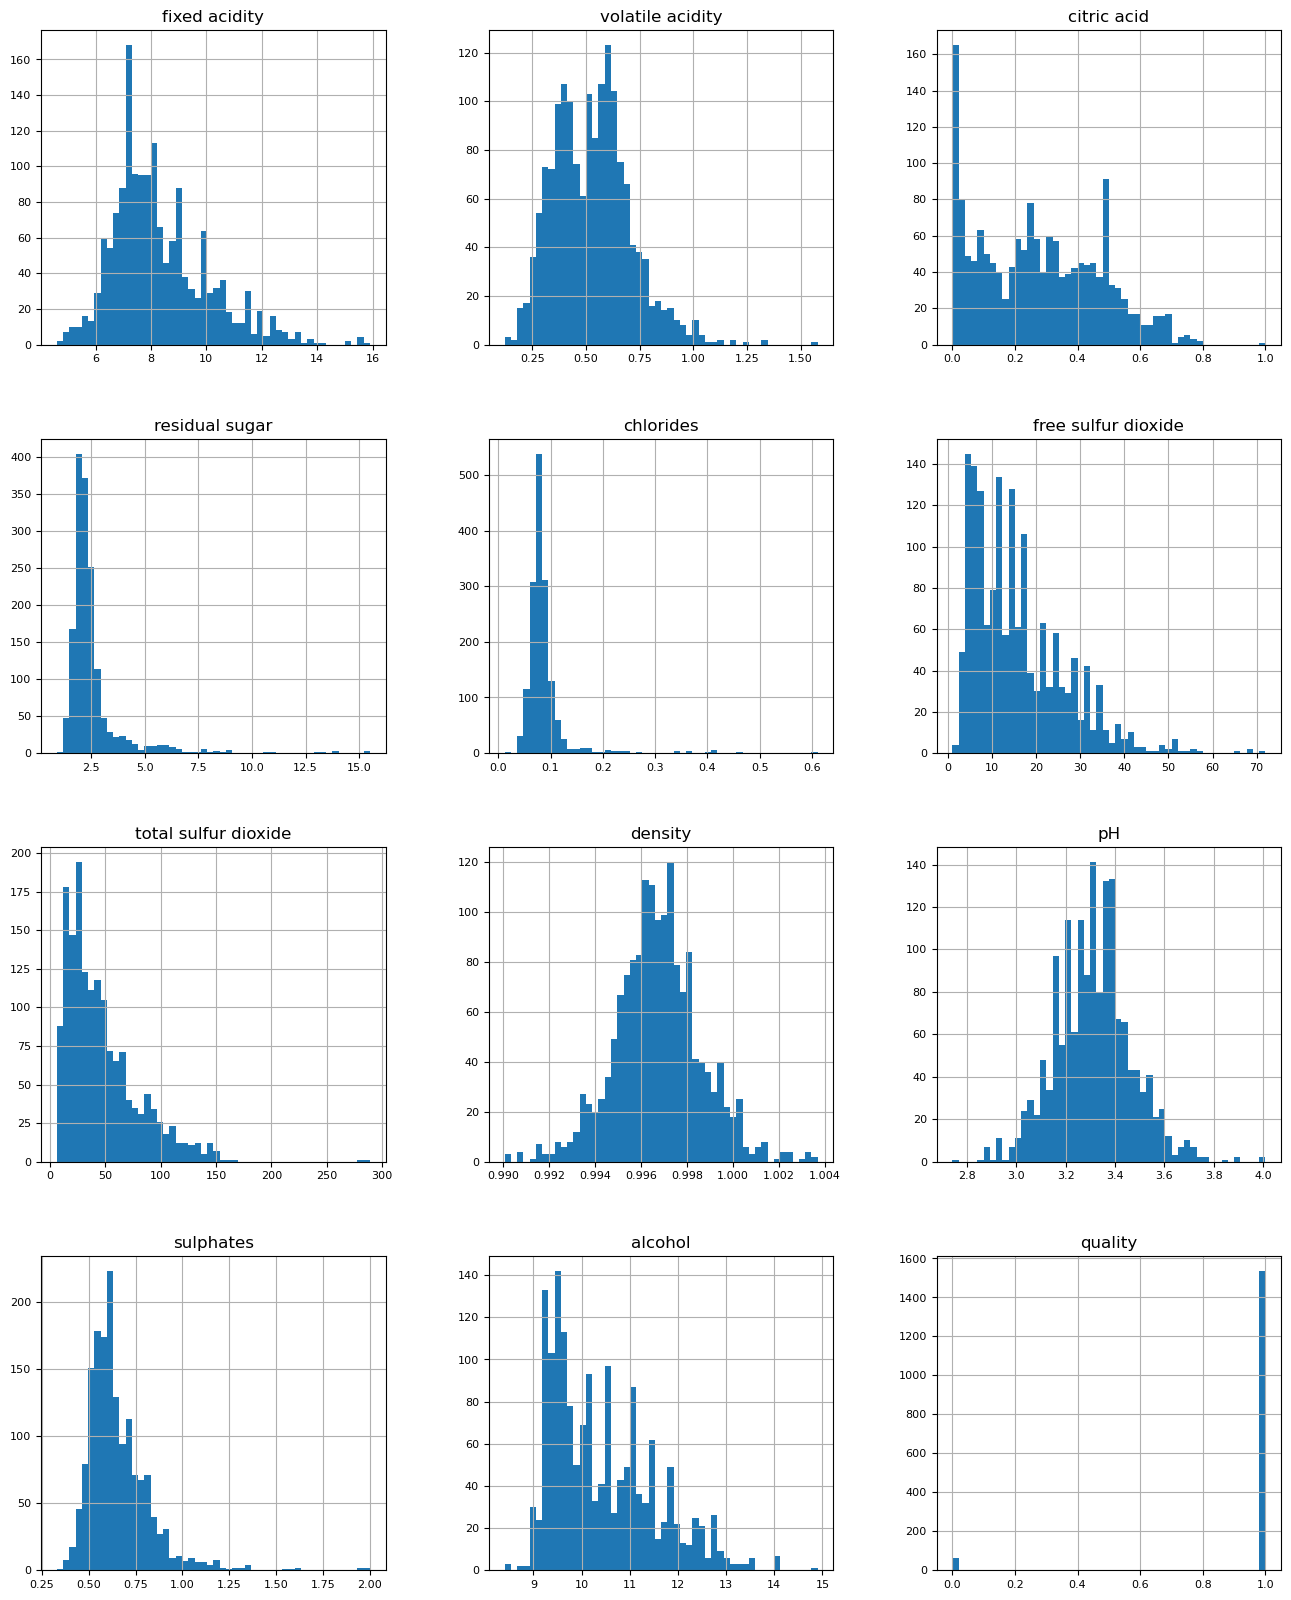

In [ ]:
df.hist(figsize=(16, 20), bins=50, xlabelsize=8, ylabelsize=8)

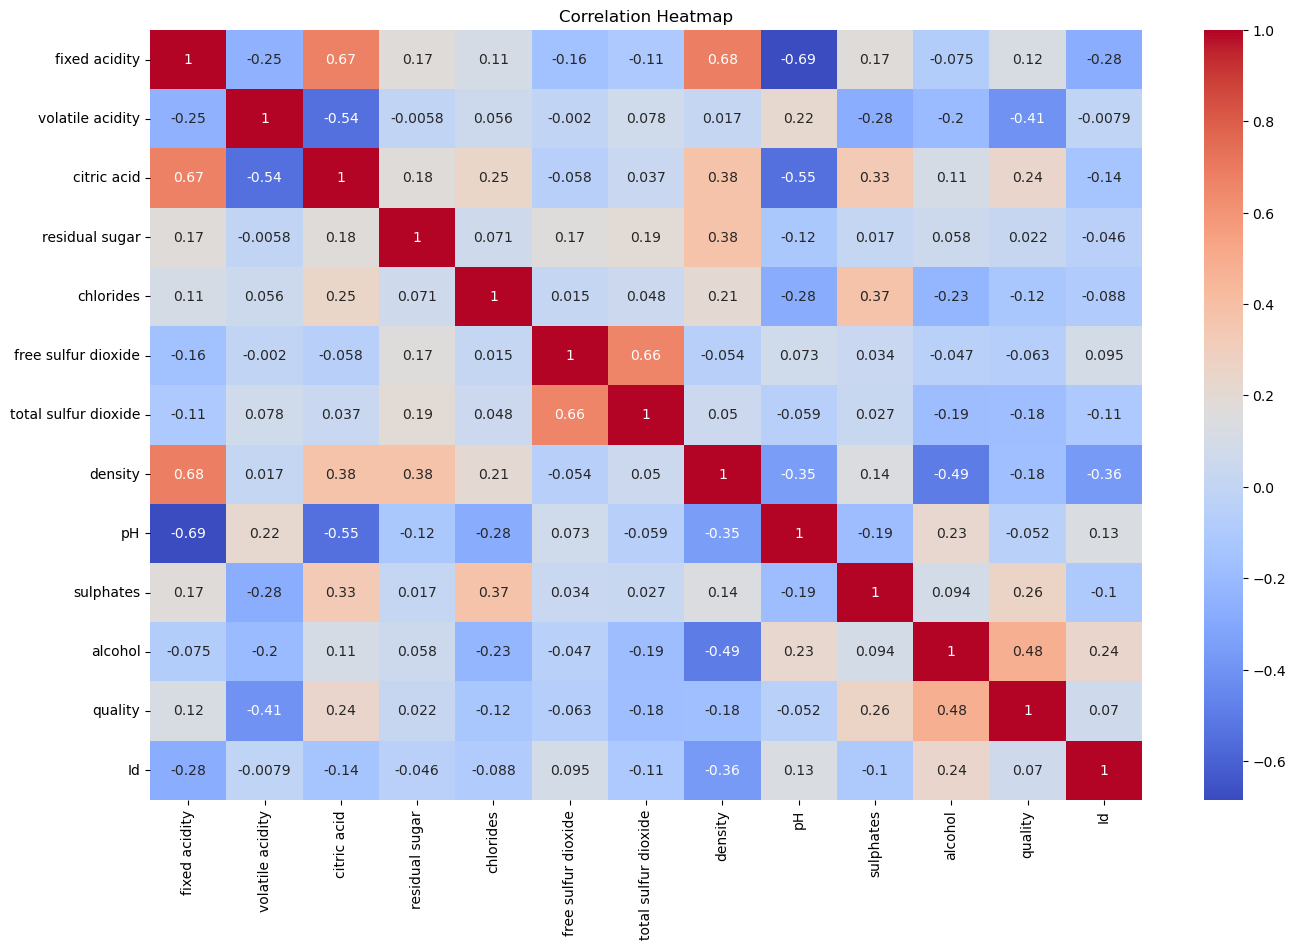

In [ ]:
# Plot Heatmap
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(16, 10))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

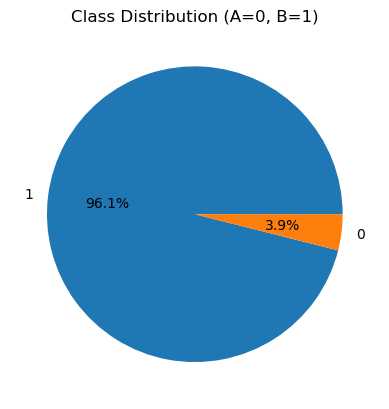

In [ ]:
# pi chart (class distribution)
import matplotlib.pyplot as plt

df['quality'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%'
)

plt.title("Class Distribution (A=0, B=1)")
plt.ylabel("")
plt.show()

In [ ]:
X = df.drop("quality", axis=1)
y = df["quality"]

In [ ]:
# Train and split data
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
X_train

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol
493,8.7,0.690,0.31,3.0,0.086,23.0,81.0,1.00020,3.48,0.74,11.6
354,6.1,0.210,0.40,1.4,0.066,40.5,165.0,0.99120,3.25,0.59,11.9
342,10.9,0.390,0.47,1.8,0.118,6.0,14.0,0.99820,3.30,0.75,9.8
834,8.8,0.685,0.26,1.6,0.088,16.0,23.0,0.99694,3.32,0.47,9.4
705,8.4,1.035,0.15,6.0,0.073,11.0,54.0,0.99900,3.37,0.49,9.9
...,...,...,...,...,...,...,...,...,...,...,...
1130,9.1,0.600,0.00,1.9,0.058,5.0,10.0,0.99770,3.18,0.63,10.4
1294,8.2,0.635,0.10,2.1,0.073,25.0,60.0,0.99638,3.29,0.75,10.9
860,7.2,0.620,0.06,2.7,0.077,15.0,85.0,0.99746,3.51,0.54,9.5
1459,7.9,0.200,0.35,1.7,0.054,7.0,15.0,0.99458,3.32,0.80,11.9


In [ ]:
# Build decision tree classifier
from sklearn.tree import DecisionTreeClassifier
clf = DecisionTreeClassifier()
clf.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [ ]:
from sklearn.metrics import confusion_matrix
y_pred = clf.predict(X_test)
cm = confusion_matrix(y_test, y_pred)
tp = cm[0,0]
tn = cm[1,1]
fp = cm[1,0] # false Positive
fn = cm[0,1] # False Negative

accuaracy = (tp + tn) / cm.sum()
precision = tp / (tp + fp)
recall = tp / (tp + fn)

C:\Users\kunal\AppData\Local\Temp\ipykernel_24536\1516791349.py:8: RuntimeWarning: invalid value encountered in scalar divide
  precision = tp / (tp + fp)


In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='macro')
recall = recall_score(y_test, y_pred, average='macro')
f1 = f1_score(y_test, y_pred, average='macro') # harmoic mean of recall and precision 

c:\Users\kunal\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [ ]:
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")

Accuracy: 0.9656
Precision: 0.4828
Recall: 0.5000
F1 Score: 0.4913


In [ ]:
# Build Decision Tree Classifier with hyperparameters

from sklearn.tree import DecisionTreeClassifier 
clf = DecisionTreeClassifier(
    criterion='gini',
    max_depth=3,
    splitter='best',
    min_samples_split=10,
    min_samples_leaf=2
)
clf.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,3
,min_samples_split,10
,min_samples_leaf,2
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [ ]:
y_pred = clf.predict(X_test)

In [ ]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred)

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='macro')
recall = recall_score(y_test, y_pred, average='macro')
f1 = f1_score(y_test, y_pred, average='macro')

In [ ]:
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")

Accuracy: 0.9594
Precision: 0.4827
Recall: 0.4968
F1 Score: 0.4896


In [ ]:
#parameter tuning

accuracy_dict = dict()
for depth in range(1, 11):
    for split in range(2,10):
        for leaf in range(1,5):
            clf = DecisionTreeClassifier(
                max_depth=depth,
                min_samples_split=split,
                min_samples_leaf=leaf
            )
            clf.fit(X_train, y_train)
            y_pred = clf.predict(X_test)
            accuracy = accuracy_score(y_test, y_pred)
            accuracy_dict[(depth, split, leaf)] = accuracy
            print(f"Depth: {depth}, Split: {split}, Leaf: {leaf} => Accuracy: {accuracy:.4f}")

Depth: 1, Split: 2, Leaf: 1 => Accuracy: 0.9656
Depth: 1, Split: 2, Leaf: 2 => Accuracy: 0.9656
Depth: 1, Split: 2, Leaf: 3 => Accuracy: 0.9656
Depth: 1, Split: 2, Leaf: 4 => Accuracy: 0.9656
Depth: 1, Split: 3, Leaf: 1 => Accuracy: 0.9656
Depth: 1, Split: 3, Leaf: 2 => Accuracy: 0.9656
Depth: 1, Split: 3, Leaf: 3 => Accuracy: 0.9656
Depth: 1, Split: 3, Leaf: 4 => Accuracy: 0.9656
Depth: 1, Split: 4, Leaf: 1 => Accuracy: 0.9656
Depth: 1, Split: 4, Leaf: 2 => Accuracy: 0.9656
Depth: 1, Split: 4, Leaf: 3 => Accuracy: 0.9656
Depth: 1, Split: 4, Leaf: 4 => Accuracy: 0.9656
Depth: 1, Split: 5, Leaf: 1 => Accuracy: 0.9656
Depth: 1, Split: 5, Leaf: 2 => Accuracy: 0.9656
Depth: 1, Split: 5, Leaf: 3 => Accuracy: 0.9656
Depth: 1, Split: 5, Leaf: 4 => Accuracy: 0.9656
Depth: 1, Split: 6, Leaf: 1 => Accuracy: 0.9656
Depth: 1, Split: 6, Leaf: 2 => Accuracy: 0.9656
Depth: 1, Split: 6, Leaf: 3 => Accuracy: 0.9656
Depth: 1, Split: 6, Leaf: 4 => Accuracy: 0.9656
Depth: 1, Split: 7, Leaf: 1 => Accuracy:

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score
import time

param_grid = {
    'max_depth': [3,5,10,None],
    'min_samples_split': [2,5,10],
    'criterion': ['gini','entropy']
}

start = time.time()

grid_dt = GridSearchCV(DecisionTreeClassifier(), param_grid, cv=5)
grid_dt.fit(X_train, y_train)

end = time.time()

best_dt = grid_dt.best_estimator_

y_pred = best_dt.predict(X_test)

acc_dt = accuracy_score(y_test, y_pred)

print("Best Parameters:", grid_dt.best_params_)
print("Accuracy:", acc_dt)
print("Time Taken:", end-start)


Best Parameters: {'criterion': 'entropy', 'max_depth': 3, 'min_samples_split': 2}
Accuracy: 0.965625
Time Taken: 0.8353028297424316


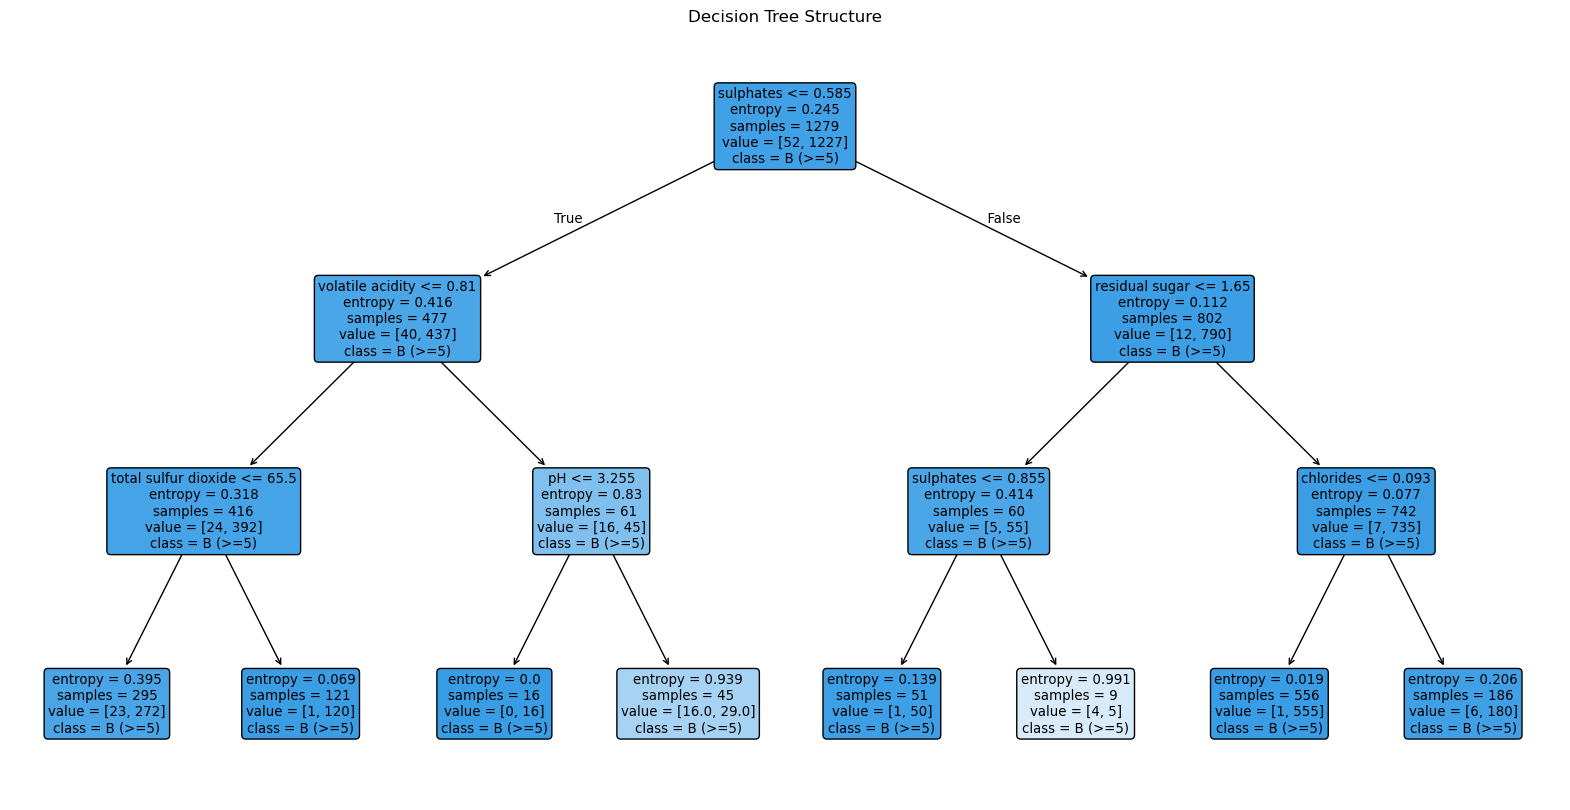

In [ ]:
# Decision Tree diagram
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(20,10))

plot_tree(best_dt,
          feature_names=X.columns,
          class_names=["A (<5)", "B (>=5)"],
          filled=True,
          rounded=True)

plt.title("Decision Tree Structure")
plt.show()

## Random Forest and Decision Tree Comparison (Grid, Random, Halving)

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from sklearn.experimental import enable_halving_search_cv  # noqa
from sklearn.model_selection import HalvingGridSearchCV
import time
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import randint

# Dictionary to store results
results = []


In [ ]:
# Decision Tree Hyperparameter Space
dt_param_grid = {
    'max_depth': [3, 5, 10, None],
    'min_samples_split': [2, 5, 10],
    'criterion': ['gini', 'entropy']
}

dt_param_dist = {
    'max_depth': [3, 5, 10, None],
    'min_samples_split': randint(2, 11),
    'criterion': ['gini', 'entropy']
}

# 1. Grid Search for Decision Tree
start_time = time.time()
dt_grid = GridSearchCV(DecisionTreeClassifier(random_state=42), dt_param_grid, cv=5, n_jobs=-1)
dt_grid.fit(X_train, y_train)
dt_grid_time = time.time() - start_time
dt_grid_acc = accuracy_score(y_test, dt_grid.predict(X_test))
results.append({'Model': 'Decision Tree', 'Search Strategy': 'Grid Search', 'Accuracy': dt_grid_acc, 'Time (s)': dt_grid_time, 'Best Params': str(dt_grid.best_params_)})

# 2. Random Search for Decision Tree
start_time = time.time()
dt_random = RandomizedSearchCV(DecisionTreeClassifier(random_state=42), dt_param_dist, n_iter=10, cv=5, random_state=42, n_jobs=-1)
dt_random.fit(X_train, y_train)
dt_random_time = time.time() - start_time
dt_random_acc = accuracy_score(y_test, dt_random.predict(X_test))
results.append({'Model': 'Decision Tree', 'Search Strategy': 'Random Search', 'Accuracy': dt_random_acc, 'Time (s)': dt_random_time, 'Best Params': str(dt_random.best_params_)})

# 3. Successive Halving for Decision Tree
start_time = time.time()
dt_halving = HalvingGridSearchCV(DecisionTreeClassifier(random_state=42), dt_param_grid, cv=5, factor=2, random_state=42, n_jobs=-1)
dt_halving.fit(X_train, y_train)
dt_halving_time = time.time() - start_time
dt_halving_acc = accuracy_score(y_test, dt_halving.predict(X_test))
results.append({'Model': 'Decision Tree', 'Search Strategy': 'Successive Halving', 'Accuracy': dt_halving_acc, 'Time (s)': dt_halving_time, 'Best Params': str(dt_halving.best_params_)})

print("Decision Tree tuning completed.")


In [ ]:
# Random Forest Hyperparameter Space
rf_param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [3, 5, 10, None],
    'min_samples_split': [2, 5, 10]
}

rf_param_dist = {
    'n_estimators': randint(50, 150),
    'max_depth': [3, 5, 10, None],
    'min_samples_split': randint(2, 11)
}

# 1. Grid Search for Random Forest
start_time = time.time()
rf_grid = GridSearchCV(RandomForestClassifier(random_state=42), rf_param_grid, cv=5, n_jobs=-1)
rf_grid.fit(X_train, y_train)
rf_grid_time = time.time() - start_time
rf_grid_acc = accuracy_score(y_test, rf_grid.predict(X_test))
results.append({'Model': 'Random Forest', 'Search Strategy': 'Grid Search', 'Accuracy': rf_grid_acc, 'Time (s)': rf_grid_time, 'Best Params': str(rf_grid.best_params_)})

# 2. Random Search for Random Forest
start_time = time.time()
rf_random = RandomizedSearchCV(RandomForestClassifier(random_state=42), rf_param_dist, n_iter=10, cv=5, random_state=42, n_jobs=-1)
rf_random.fit(X_train, y_train)
rf_random_time = time.time() - start_time
rf_random_acc = accuracy_score(y_test, rf_random.predict(X_test))
results.append({'Model': 'Random Forest', 'Search Strategy': 'Random Search', 'Accuracy': rf_random_acc, 'Time (s)': rf_random_time, 'Best Params': str(rf_random.best_params_)})

# 3. Successive Halving for Random Forest
start_time = time.time()
rf_halving = HalvingGridSearchCV(RandomForestClassifier(random_state=42), rf_param_grid, cv=5, factor=2, random_state=42, n_jobs=-1)
rf_halving.fit(X_train, y_train)
rf_halving_time = time.time() - start_time
rf_halving_acc = accuracy_score(y_test, rf_halving.predict(X_test))
results.append({'Model': 'Random Forest', 'Search Strategy': 'Successive Halving', 'Accuracy': rf_halving_acc, 'Time (s)': rf_halving_time, 'Best Params': str(rf_halving.best_params_)})

print("Random Forest tuning completed.")


In [ ]:
# Convert results to DataFrame
results_df = pd.DataFrame(results)
display(results_df)

# Heatmap Comparison of Accuracy
heatmap_data = results_df.pivot(index='Model', columns='Search Strategy', values='Accuracy')
plt.figure(figsize=(8, 5))
sns.heatmap(heatmap_data, annot=True, cmap='coolwarm', fmt='.4f', cbar_kws={'label': 'Accuracy'})
plt.title('Accuracy Heatmap: Models vs Search Strategies', fontsize=16)
plt.tight_layout()
plt.show()

# Heatmap Comparison of Time
heatmap_time = results_df.pivot(index='Model', columns='Search Strategy', values='Time (s)')
plt.figure(figsize=(8, 5))
sns.heatmap(heatmap_time, annot=True, cmap='Reds', fmt='.2f', cbar_kws={'label': 'Time (seconds)'})
plt.title('Time Efficiency Heatmap: Models vs Search Strategies', fontsize=16)
plt.tight_layout()
plt.show()

# Performance vs Efficiency Plot (Accuracy vs Time)
plt.figure(figsize=(10, 6))
sns.scatterplot(data=results_df, x='Time (s)', y='Accuracy', hue='Model', style='Search Strategy', s=200, palette='Set1')
plt.title('Efficiency vs Performance: Hyperparameter Search Strategies', fontsize=16)
plt.xlabel('Time Taken (seconds)', fontsize=12)
plt.ylabel('Test Accuracy', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()
